In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns 



In [2]:
customers = pd.read_csv(r"D:\Downloads\QVI_purchase_behaviour.csv")
transactions = pd.read_excel(r"D:\Downloads\QVI_transaction_data.xlsx")

In [3]:

customers.shape

(72637, 3)

In [4]:
transactions.shape


(264836, 8)

In [5]:
transactions.columns


Index(['DATE', 'STORE_NBR', 'LYLTY_CARD_NBR', 'TXN_ID', 'PROD_NBR',
       'PROD_NAME', 'PROD_QTY', 'TOT_SALES'],
      dtype='object')

In [6]:

customers.columns

Index(['LYLTY_CARD_NBR', 'LIFESTAGE', 'PREMIUM_CUSTOMER'], dtype='object')

In [7]:
transactions.head(5)


,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
0,43390,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0
1,43599,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3
2,43605,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9
3,43329,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0
4,43330,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8


In [8]:
customers.head()

,LYLTY_CARD_NBR,LIFESTAGE,PREMIUM_CUSTOMER
0,1000,YOUNG SINGLES/COUPLES,Premium
1,1002,YOUNG SINGLES/COUPLES,Mainstream
2,1003,YOUNG FAMILIES,Budget
3,1004,OLDER SINGLES/COUPLES,Mainstream
4,1005,MIDAGE SINGLES/COUPLES,Mainstream


In [9]:
transactions.isnull().sum()

DATE              0
STORE_NBR         0
LYLTY_CARD_NBR    0
TXN_ID            0
PROD_NBR          0
PROD_NAME         0
PROD_QTY          0
TOT_SALES         0
dtype: int64

In [10]:
customers.isnull().sum()

LYLTY_CARD_NBR      0
LIFESTAGE           0
PREMIUM_CUSTOMER    0
dtype: int64

In [11]:
transactions.duplicated().sum()



1

In [12]:
customers.duplicated().sum()

0

In [13]:
transactions.drop_duplicates()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
0,43390,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0
1,43599,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3
2,43605,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9
3,43329,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0
4,43330,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8
...,...,...,...,...,...,...,...,...
264831,43533,272,272319,270088,89,Kettle Sweet Chilli And Sour Cream 175g,2,10.8
264832,43325,272,272358,270154,74,Tostitos Splash Of Lime 175g,1,4.4
264833,43410,272,272379,270187,51,Doritos Mexicana 170g,2,8.8
264834,43461,272,272379,270188,42,Doritos Corn Chip Mexican Jalapeno 150g,2,7.8


In [14]:
transactions.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 264836 entries, 0 to 264835
Data columns (total 8 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   DATE            264836 non-null  int64  
 1   STORE_NBR       264836 non-null  int64  
 2   LYLTY_CARD_NBR  264836 non-null  int64  
 3   TXN_ID          264836 non-null  int64  
 4   PROD_NBR        264836 non-null  int64  
 5   PROD_NAME       264836 non-null  object 
 6   PROD_QTY        264836 non-null  int64  
 7   TOT_SALES       264836 non-null  float64
dtypes: float64(1), int64(6), object(1)
memory usage: 16.2+ MB


In [15]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72637 entries, 0 to 72636
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   LYLTY_CARD_NBR    72637 non-null  int64 
 1   LIFESTAGE         72637 non-null  object
 2   PREMIUM_CUSTOMER  72637 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.7+ MB


In [16]:
customers.describe()

,LYLTY_CARD_NBR
count,7.263700e+04
mean,1.361859e+05
std,8.989293e+04
min,1.000000e+03
25%,6.620200e+04
50%,1.340400e+05
75%,2.033750e+05
max,2.373711e+06


In [17]:
transactions.describe()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_QTY,TOT_SALES
count,264836.000000,264836.00000,2.648360e+05,2.648360e+05,264836.000000,264836.000000,264836.000000
mean,43464.036260,135.08011,1.355495e+05,1.351583e+05,56.583157,1.907309,7.304200
std,105.389282,76.78418,8.057998e+04,7.813303e+04,32.826638,0.643654,3.083226
min,43282.000000,1.00000,1.000000e+03,1.000000e+00,1.000000,1.000000,1.500000
25%,43373.000000,70.00000,7.002100e+04,6.760150e+04,28.000000,2.000000,5.400000
50%,43464.000000,130.00000,1.303575e+05,1.351375e+05,56.000000,2.000000,7.400000
75%,43555.000000,203.00000,2.030942e+05,2.027012e+05,85.000000,2.000000,9.200000
max,43646.000000,272.00000,2.373711e+06,2.415841e+06,114.000000,200.000000,650.000000


In [18]:
transactions["PROD_NAME"].value_counts().head(20)

PROD_NAME
Kettle Mozzarella   Basil & Pesto 175g      3304
Kettle Tortilla ChpsHny&Jlpno Chili 150g    3296
Cobs Popd Swt/Chlli &Sr/Cream Chips 110g    3269
Tyrrells Crisps     Ched & Chives 165g      3268
Cobs Popd Sea Salt  Chips 110g              3265
Kettle 135g Swt Pot Sea Salt                3257
Tostitos Splash Of  Lime 175g               3252
Infuzions Thai SweetChili PotatoMix 110g    3242
Smiths Crnkle Chip  Orgnl Big Bag 380g      3233
Thins Potato Chips  Hot & Spicy 175g        3229
Kettle Sensations   Camembert & Fig 150g    3219
Doritos Corn Chips  Cheese Supreme 170g     3217
Pringles Barbeque   134g                    3210
Doritos Corn Chip Mexican Jalapeno 150g     3204
Kettle Sweet Chilli And Sour Cream 175g     3200
Smiths Crinkle Chips Salt & Vinegar 330g    3197
Thins Chips Light&  Tangy 175g              3188
Dorito Corn Chp     Supreme 380g            3185
Pringles Sweet&Spcy BBQ 134g                3177
Infuzions BBQ Rib   Prawn Crackers 110g     3174
Name: coun

In [19]:
transactions = transactions[
    ~transactions["PROD_NAME"].str.contains("Salsa",case=False)
]

In [20]:
transactions[transactions["PROD_NAME"].str.contains("Salsa", case=False, na=False)]

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES


In [21]:
transactions["DATE"].head()

0    43390
1    43599
2    43605
3    43329
4    43330
Name: DATE, dtype: int64

In [22]:
transactions["DATE"] = pd.to_datetime(
    transactions["DATE"],
    unit="D",
    origin="1899-12-30"
)

In [23]:
transactions["DATE"].head()

0   2018-10-17
1   2019-05-14
2   2019-05-20
3   2018-08-17
4   2018-08-18
Name: DATE, dtype: datetime64[ns]

In [24]:
transactions.describe()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_QTY,TOT_SALES
count,246742,246742.000000,2.467420e+05,2.467420e+05,246742.000000,246742.000000,246742.000000
mean,2018-12-30 01:19:01.211467520,135.051098,1.355310e+05,1.351311e+05,56.351789,1.908062,7.321322
min,2018-07-01 00:00:00,1.000000,1.000000e+03,1.000000e+00,1.000000,1.000000,1.700000
25%,2018-09-30 00:00:00,70.000000,7.001500e+04,6.756925e+04,26.000000,2.000000,5.800000
50%,2018-12-30 00:00:00,130.000000,1.303670e+05,1.351830e+05,53.000000,2.000000,7.400000
75%,2019-03-31 00:00:00,203.000000,2.030840e+05,2.026538e+05,87.000000,2.000000,8.800000
max,2019-06-30 00:00:00,272.000000,2.373711e+06,2.415841e+06,114.000000,200.000000,650.000000
std,NaN,76.787096,8.071528e+04,7.814772e+04,33.695428,0.659831,3.077828


In [25]:
transactions[transactions["PROD_QTY"] == 200]

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
69762,2018-08-19,226,226000,226201,4,Dorito Corn Chp Supreme 380g,200,650.0
69763,2019-05-20,226,226000,226210,4,Dorito Corn Chp Supreme 380g,200,650.0


In [26]:
transactions.sort_values("TOT_SALES", ascending=False).head(10)

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
69762,2018-08-19,226,226000,226201,4,Dorito Corn Chp Supreme 380g,200,650.0
69763,2019-05-20,226,226000,226210,4,Dorito Corn Chp Supreme 380g,200,650.0
69496,2018-08-15,49,49303,45789,14,Smiths Crnkle Chip Orgnl Big Bag 380g,5,29.5
117850,2019-05-19,194,194308,194516,14,Smiths Crnkle Chip Orgnl Big Bag 380g,5,29.5
171815,2018-08-17,24,24095,20797,14,Smiths Crnkle Chip Orgnl Big Bag 380g,5,29.5
150683,2019-05-20,118,118021,120799,14,Smiths Crnkle Chip Orgnl Big Bag 380g,5,29.5
5179,2018-08-15,94,94148,93390,14,Smiths Crnkle Chip Orgnl Big Bag 380g,5,29.5
55558,2019-05-14,190,190113,190914,14,Smiths Crnkle Chip Orgnl Big Bag 380g,5,29.5
184969,2019-05-20,44,44350,40394,14,Smiths Crnkle Chip Orgnl Big Bag 380g,5,29.5
135346,2018-08-15,101,101110,100677,16,Smiths Crinkle Chips Salt & Vinegar 330g,5,28.5


In [27]:
transactions = transactions[transactions["LYLTY_CARD_NBR"] != 226000]

In [28]:
df = pd.merge(
    transactions,
    customers,
    on="LYLTY_CARD_NBR",
    how="left"
)

In [29]:
df.head()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,LIFESTAGE,PREMIUM_CUSTOMER
0,2018-10-17,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0,YOUNG SINGLES/COUPLES,Premium
1,2019-05-14,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3,MIDAGE SINGLES/COUPLES,Budget
2,2019-05-20,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9,MIDAGE SINGLES/COUPLES,Budget
3,2018-08-17,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0,MIDAGE SINGLES/COUPLES,Budget
4,2018-08-18,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8,MIDAGE SINGLES/COUPLES,Budget


In [30]:
df.shape

(246740, 10)

In [31]:
df.isnull().sum()

DATE                0
STORE_NBR           0
LYLTY_CARD_NBR      0
TXN_ID              0
PROD_NBR            0
PROD_NAME           0
PROD_QTY            0
TOT_SALES           0
LIFESTAGE           0
PREMIUM_CUSTOMER    0
dtype: int64

In [32]:
df["PACK_SIZE"] = df["PROD_NAME"].str.extract(r'(\d+)').astype(int)

In [33]:
df[["PROD_NAME", "PACK_SIZE"]].head(10)

,PROD_NAME,PACK_SIZE
0,Natural Chip Compny SeaSalt175g,175
1,CCs Nacho Cheese 175g,175
2,Smiths Crinkle Cut Chips Chicken 170g,170
3,Smiths Chip Thinly S/Cream&Onion 175g,175
4,Kettle Tortilla ChpsHny&Jlpno Chili 150g,150
5,Smiths Crinkle Chips Salt & Vinegar 330g,330
6,Grain Waves Sweet Chilli 210g,210
7,Doritos Corn Chip Mexican Jalapeno 150g,150
8,Grain Waves Sour Cream&Chives 210G,210
9,Smiths Crinkle Chips Salt & Vinegar 330g,330


In [34]:
df["BRAND"] = df["PROD_NAME"].str.split().str[0]

In [35]:
df[["PROD_NAME", "BRAND"]].head(10)

,PROD_NAME,BRAND
0,Natural Chip Compny SeaSalt175g,Natural
1,CCs Nacho Cheese 175g,CCs
2,Smiths Crinkle Cut Chips Chicken 170g,Smiths
3,Smiths Chip Thinly S/Cream&Onion 175g,Smiths
4,Kettle Tortilla ChpsHny&Jlpno Chili 150g,Kettle
5,Smiths Crinkle Chips Salt & Vinegar 330g,Smiths
6,Grain Waves Sweet Chilli 210g,Grain
7,Doritos Corn Chip Mexican Jalapeno 150g,Doritos
8,Grain Waves Sour Cream&Chives 210G,Grain
9,Smiths Crinkle Chips Salt & Vinegar 330g,Smiths


In [36]:
df["UNIT_PRICE"] = df["TOT_SALES"] / df["PROD_QTY"]

In [37]:
df[["TOT_SALES", "PROD_QTY", "UNIT_PRICE"]].head()

,TOT_SALES,PROD_QTY,UNIT_PRICE
0,6.0,2,3.00
1,6.3,3,2.10
2,2.9,2,1.45
3,15.0,5,3.00
4,13.8,3,4.60


In [38]:
df["BRAND"] = df["BRAND"].replace({
    "Dorito": "Doritos",
    "Infzns": "Infuzions",
    "Red": "RRD",
    "WW": "Woolworths"
})

In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 246740 entries, 0 to 246739
Data columns (total 13 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   DATE              246740 non-null  datetime64[ns]
 1   STORE_NBR         246740 non-null  int64         
 2   LYLTY_CARD_NBR    246740 non-null  int64         
 3   TXN_ID            246740 non-null  int64         
 4   PROD_NBR          246740 non-null  int64         
 5   PROD_NAME         246740 non-null  object        
 6   PROD_QTY          246740 non-null  int64         
 7   TOT_SALES         246740 non-null  float64       
 8   LIFESTAGE         246740 non-null  object        
 9   PREMIUM_CUSTOMER  246740 non-null  object        
 10  PACK_SIZE         246740 non-null  int32         
 11  BRAND             246740 non-null  object        
 12  UNIT_PRICE        246740 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int32(1), int64(5), objec

In [40]:
print("Total Sales: $", round(df["TOT_SALES"].sum(), 2))
print("Total Transactions:", df["TXN_ID"].nunique())
print("Total Customers:", df["LYLTY_CARD_NBR"].nunique())
print("Total Quantity Sold:", df["PROD_QTY"].sum())

Total Sales: $ 1805177.7
Total Transactions: 245255
Total Customers: 71287
Total Quantity Sold: 470399


In [41]:
brand_sales = (
    df.groupby("BRAND")["TOT_SALES"]
      .sum()
      .sort_values(ascending=False)
)

print(brand_sales)

BRAND
Kettle        390239.8
Doritos       226329.9
Smiths        202908.6
Pringles      177655.5
Infuzions      99047.6
Thins          88852.5
RRD            87607.5
Twisties       81522.1
Tostitos       79789.6
Cobs           70569.8
Tyrrells       51647.4
Grain          43048.8
Woolworths     41059.1
Cheezels       40029.9
Natural        34272.0
CCs            18078.9
Cheetos        16884.5
Smith          14583.4
GrnWves         8568.4
NCC             8046.0
French          7929.0
Burger          6831.0
Snbts           5076.2
Sunbites        4600.2
Name: TOT_SALES, dtype: float64


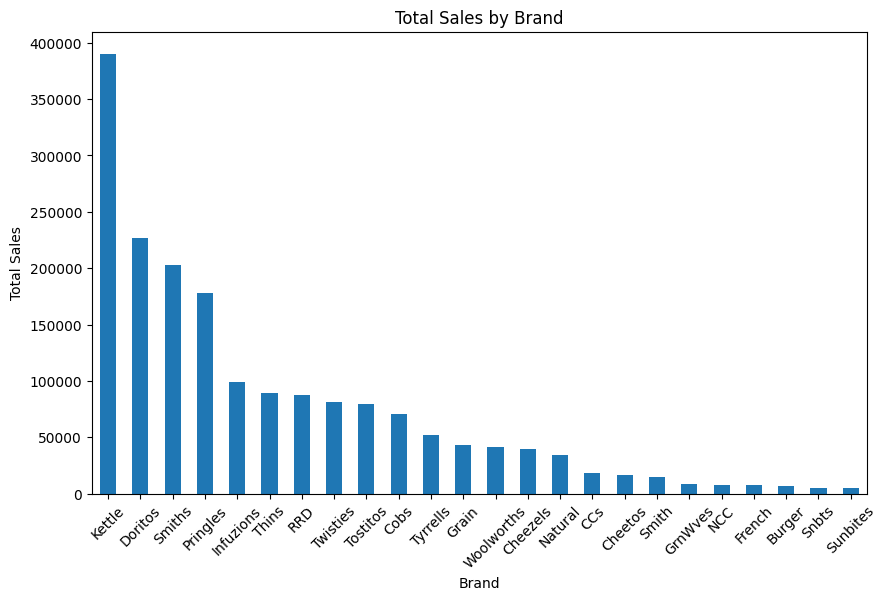

In [42]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
brand_sales.plot(kind="bar")
plt.title("Total Sales by Brand")
plt.xlabel("Brand")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()

# Brand with highest sales = Kettle
# Brand with lowest sales = sunbites

In [43]:
pack_sales = (
    df.groupby("PACK_SIZE")["TOT_SALES"]
      .sum()
      .sort_values(ascending=False)
)

print(pack_sales)

PACK_SIZE
175    485437.4
150    289681.8
134    177655.5
110    162765.4
170    146673.0
330    136794.3
165    101360.6
380     75419.6
270     55425.4
210     43048.8
250     26096.7
135     26090.4
200     16007.5
190     14412.9
160     10647.6
90       9676.4
180      8568.4
70       6852.0
220      6831.0
125      5733.0
Name: TOT_SALES, dtype: float64


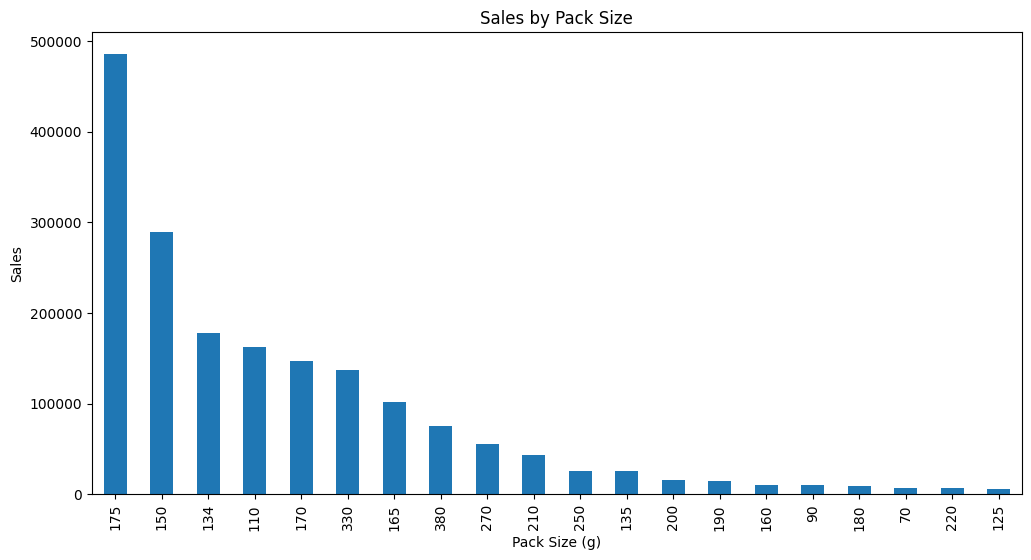

In [44]:
plt.figure(figsize=(12,6))
pack_sales.plot(kind="bar")
plt.title("Sales by Pack Size")
plt.xlabel("Pack Size (g)")
plt.ylabel("Sales")
plt.show()

# Which pack size sells the most?  -> 175
# Are customers buying larger packs or smaller packs? -> Are customers buying larger packs or smaller packs?

In [45]:
life_sales = (
    df.groupby("LIFESTAGE")["TOT_SALES"]
      .sum()
      .sort_values(ascending=False)
)

print(life_sales)

LIFESTAGE
OLDER SINGLES/COUPLES     376019.65
RETIREES                  342381.90
OLDER FAMILIES            328519.90
YOUNG FAMILIES            294627.90
YOUNG SINGLES/COUPLES     243756.60
MIDAGE SINGLES/COUPLES    172523.80
NEW FAMILIES               47347.95
Name: TOT_SALES, dtype: float64


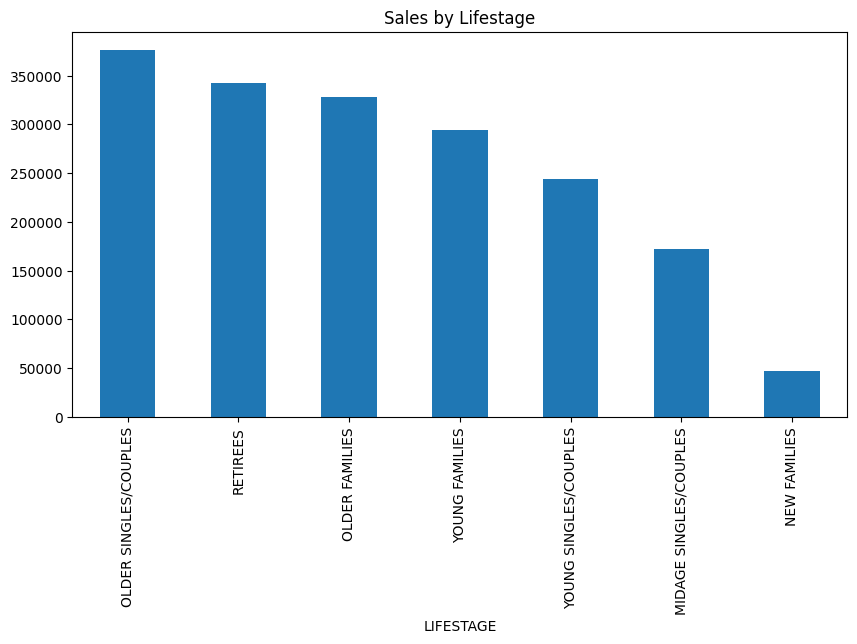

In [46]:
life_sales.plot(kind="bar", figsize=(10,5))
plt.title("Sales by Lifestage")
plt.show()

In [47]:
premium_sales = (
    df.groupby("PREMIUM_CUSTOMER")["TOT_SALES"]
      .sum()
)

print(premium_sales)

PREMIUM_CUSTOMER
Budget        631406.85
Mainstream    700865.40
Premium       472905.45
Name: TOT_SALES, dtype: float64


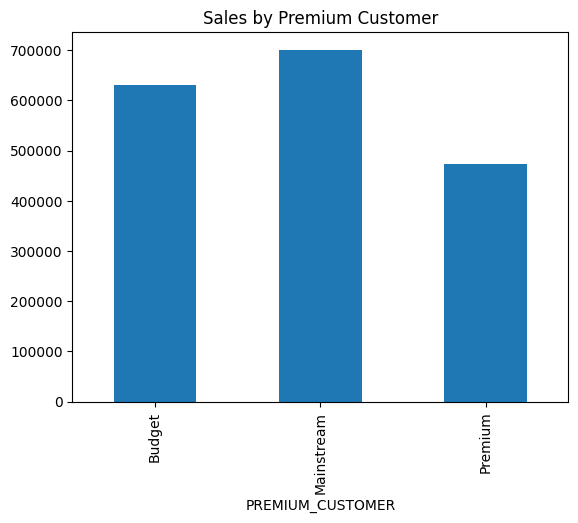

In [48]:
premium_sales.plot(kind="bar")
plt.title("Sales by Premium Customer")
plt.show()

In [49]:
segment_sales = pd.pivot_table(
    df,
    values="TOT_SALES",
    index="LIFESTAGE",
    columns="PREMIUM_CUSTOMER",
    aggfunc="sum"
)

segment_sales

PREMIUM_CUSTOMER,Budget,Mainstream,Premium
LIFESTAGE,,,
MIDAGE SINGLES/COUPLES,33345.70,84734.25,54443.85
NEW FAMILIES,20607.45,15979.70,10760.80
OLDER FAMILIES,156863.75,96413.55,75242.60
OLDER SINGLES/COUPLES,127833.60,124648.50,123537.55
RETIREES,105916.30,145168.95,91296.65
YOUNG FAMILIES,129717.95,86338.25,78571.70
YOUNG SINGLES/COUPLES,57122.10,147582.20,39052.30


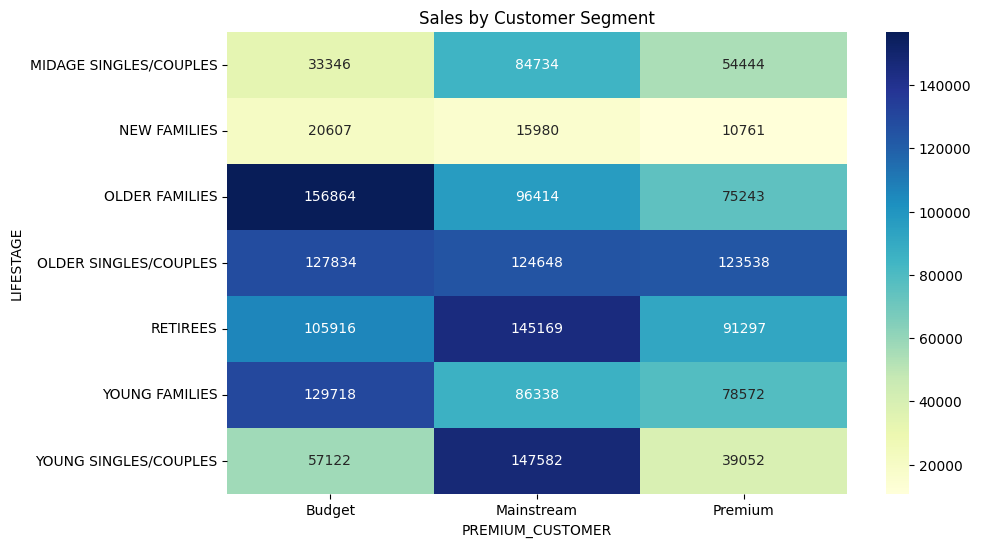

In [50]:

plt.figure(figsize=(10,6))
sns.heatmap(segment_sales, annot=True, fmt=".0f", cmap="YlGnBu")
plt.title("Sales by Customer Segment")
plt.show()

# Which combination of Lifestage and Premium Customer contributes the most sales?  -> Older Families 

In [51]:
segment_customers = pd.pivot_table(
    df,
    values="LYLTY_CARD_NBR",
    index="LIFESTAGE",
    columns="PREMIUM_CUSTOMER",
    aggfunc=pd.Series.nunique
)

segment_customers

PREMIUM_CUSTOMER,Budget,Mainstream,Premium
LIFESTAGE,,,
MIDAGE SINGLES/COUPLES,1474,3298,2369
NEW FAMILIES,1087,830,575
OLDER FAMILIES,4611,2788,2231
OLDER SINGLES/COUPLES,4849,4858,4682
RETIREES,4385,6358,3812
YOUNG FAMILIES,3953,2685,2398
YOUNG SINGLES/COUPLES,3647,7917,2480


# More customers, or Customers spending more.

In [52]:
avg_spend = (
    df.groupby("LYLTY_CARD_NBR")["TOT_SALES"]
      .sum()
      .mean()
)

print(avg_spend)

25.322677346500765


In [53]:
price_segment = pd.pivot_table(
    df,
    values="UNIT_PRICE",
    index="LIFESTAGE",
    columns="PREMIUM_CUSTOMER",
    aggfunc="mean"
)

price_segment

PREMIUM_CUSTOMER,Budget,Mainstream,Premium
LIFESTAGE,,,
MIDAGE SINGLES/COUPLES,3.743328,3.994241,3.770698
NEW FAMILIES,3.917688,3.916133,3.872110
OLDER FAMILIES,3.745340,3.737077,3.717000
OLDER SINGLES/COUPLES,3.882096,3.814665,3.893182
RETIREES,3.924404,3.844294,3.920942
YOUNG FAMILIES,3.760737,3.724533,3.762150
YOUNG SINGLES/COUPLES,3.657366,4.065642,3.665414


In [54]:
# Number of unique customers
segment_customers = pd.pivot_table(
    df,
    values="LYLTY_CARD_NBR",
    index="LIFESTAGE",
    columns="PREMIUM_CUSTOMER",
    aggfunc=pd.Series.nunique
)

print(segment_customers)

PREMIUM_CUSTOMER        Budget  Mainstream  Premium
LIFESTAGE                                          
MIDAGE SINGLES/COUPLES    1474        3298     2369
NEW FAMILIES              1087         830      575
OLDER FAMILIES            4611        2788     2231
OLDER SINGLES/COUPLES     4849        4858     4682
RETIREES                  4385        6358     3812
YOUNG FAMILIES            3953        2685     2398
YOUNG SINGLES/COUPLES     3647        7917     2480


In [55]:
# Average transaction value
avg_sales = pd.pivot_table(
    df,
    values="TOT_SALES",
    index="LIFESTAGE",
    columns="PREMIUM_CUSTOMER",
    aggfunc="mean"
)

print(avg_sales)

PREMIUM_CUSTOMER          Budget  Mainstream   Premium
LIFESTAGE                                             
MIDAGE SINGLES/COUPLES  7.108442    7.637156  7.152371
NEW FAMILIES            7.297256    7.313364  7.231720
OLDER FAMILIES          7.291241    7.281440  7.232779
OLDER SINGLES/COUPLES   7.444305    7.306049  7.459997
RETIREES                7.445786    7.269352  7.461315
YOUNG FAMILIES          7.302705    7.226772  7.285951
YOUNG SINGLES/COUPLES   6.663023    7.551279  6.673325


In [56]:
# Average unit price
unit_price = pd.pivot_table(
    df,
    values="UNIT_PRICE",
    index="LIFESTAGE",
    columns="PREMIUM_CUSTOMER",
    aggfunc="mean"
)

print(unit_price)

PREMIUM_CUSTOMER          Budget  Mainstream   Premium
LIFESTAGE                                             
MIDAGE SINGLES/COUPLES  3.743328    3.994241  3.770698
NEW FAMILIES            3.917688    3.916133  3.872110
OLDER FAMILIES          3.745340    3.737077  3.717000
OLDER SINGLES/COUPLES   3.882096    3.814665  3.893182
RETIREES                3.924404    3.844294  3.920942
YOUNG FAMILIES          3.760737    3.724533  3.762150
YOUNG SINGLES/COUPLES   3.657366    4.065642  3.665414
